In [9]:
import os
print(os.getcwd())

/Users/aislingwallace/Downloads/TimeSeries-Project-main


In [10]:
from pathlib import Path

src = Path("improvements/mlp_multirocket.py")
dst = Path("improvements/rf_multirocket.py")

text = src.read_text()

text = text.replace(
    "from sklearn.neural_network import MLPClassifier\nfrom sklearn.pipeline import make_pipeline\nfrom sklearn.preprocessing import StandardScaler\n",
    "from sklearn.ensemble import RandomForestClassifier\n"
)

text = text.replace(
    'classifier="mlp"',
    'classifier="rf"'
)

text = text.replace(
    """        if self.clf.lower() == "mlp":
            self.classifier = make_pipeline(
                StandardScaler(),
                MLPClassifier(
                    hidden_layer_sizes=(100,),
                    random_state=42
                )
            )
        else:
            self.classifier = LogisticRegression(
                num_features=x_train_transform.shape[1],
                max_epochs=200,
            )""",
    """        if self.clf.lower() == "rf":
            self.classifier = RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        elif self.clf.lower() == "mlp":
            raise ValueError("This RF file is for classifier='rf'. Use mlp_multirocket.py for MLP experiments.")
        else:
            self.classifier = LogisticRegression(
                num_features=x_train_transform.shape[1],
                max_epochs=200,
            )"""
)

dst.write_text(text)
print(f"Created: {dst}")

Created: improvements/rf_multirocket.py


In [11]:
rf_text = Path("improvements/rf_multirocket.py").read_text()
print("RandomForestClassifier" in rf_text)
print('classifier="rf"' in rf_text)
print('self.clf.lower() == "rf"' in rf_text)

True
True
True


In [12]:
src_main = Path("main_ucr_mlp.py")
dst_main = Path("main_ucr_rf.py")

main_text = src_main.read_text()

main_text = main_text.replace(
    "from improvements.mlp_multirocket import MultiRocket",
    "from improvements.rf_multirocket import MultiRocket"
)

main_text = main_text.replace(
    'classifier_name = "mlp_MultiRocket_{}".format(num_features)',
    'classifier_name = "rf_MultiRocket_{}".format(num_features)'
)

main_text = main_text.replace(
    'output_dir = "{}/mlp_multirocket/resample_{}/{}/{}/".format(',
    'output_dir = "{}/rf_multirocket/resample_{}/{}/{}/".format('
)

main_text = main_text.replace(
    'classifier="mlp",                 # HERE',
    'classifier="rf",                  # RF version'
)

dst_main.write_text(main_text)
print(f"Created: {dst_main}")

Created: main_ucr_rf.py


In [13]:
new_main = Path("main_ucr_rf.py").read_text()

checks = {
    "rf import": "from improvements.rf_multirocket import MultiRocket" in new_main,
    "rf classifier name": 'rf_MultiRocket_' in new_main,
    "rf output dir": "/rf_multirocket/" in new_main,
    "rf arg": 'classifier="rf"' in new_main
}
checks

{'rf import': True,
 'rf classifier name': True,
 'rf output dir': True,
 'rf arg': True}

In [14]:
from improvements.rf_multirocket import MultiRocket
print("RF MultiRocket import worked")

RF MultiRocket import worked


In [15]:
import sys
import subprocess

cmd = [
    sys.executable, "main_ucr_rf.py",
    "-d", "data/sample/",
    "-p", "ECG200",
    "-n", "9600",
    "-v", "2"
]

result = subprocess.run(cmd, capture_output=True, text=True)

print("RETURN CODE:", result.returncode)
print("\nSTDOUT:\n", result.stdout)
print("\nSTDERR:\n", result.stderr)

RETURN CODE: 0

STDOUT:
Starting Experiments
Data path: data/sample/
Output Dir: /Users/aislingwallace/Downloads/TimeSeries-Project-main/output//rf_multirocket/resample_0/rf_MultiRocket_9600/ECG200/
Iteration: 0
Problem: ECG200
Number of Features: 9600
Loading data
[MultiRocket] Creating MultiRocket with 1200 kernels
[MultiRocket] Training with training set of (100, 96)
[MultiRocket] Kernels applied!, took 0.026027667001471855s
[MultiRocket] Transformed Shape (100, 9408)
[MultiRocket] Training
[MultiRocket] Training done!, took 0.154s
[MultiRocket] Predicting
Kernels applied!, took 0.015s. Transformed shape: (100, 9408).
[MultiRocket] Predicting completed, took 0.014s
             timestamp  itr           classifier  num_features dataset  \
0  2026-04-03 13:56:26    0  rf_MultiRocket_9600          9600  ECG200   

   train_acc  train_time  test_acc  test_time  generate_kernel_time  \
0         -1    0.154166      0.88   0.013853              0.010482   

   apply_kernel_on_train_time  

In [16]:
from pathlib import Path
import pandas as pd

rf_csvs = list(Path("output/rf_multirocket").rglob("results.csv"))
print(rf_csvs[-1] if rf_csvs else "No RF results found")

if rf_csvs:
    rf_df = pd.read_csv(rf_csvs[-1])
    display(rf_df)

output/rf_multirocket/resample_0/rf_MultiRocket_9600/ECG200/results.csv


,timestamp,itr,classifier,num_features,dataset,train_acc,train_time,test_acc,test_time,generate_kernel_time,apply_kernel_on_train_time,apply_kernel_on_test_time,train_transform_time,test_transform_time,physical_cores,logical_cores,max_freq,min_freq,memory
0,2026-04-03 13:56:26,0,rf_MultiRocket_9600,9600,ECG200,-1,0.154166,0.88,0.013853,0.010482,0.011448,0.014811,0.000021,0.000076,8,8,3204,600,9.0


In [17]:
datasets = [
    "InsectWingbeatSound",
    "StarLightCurves"
]

for ds in datasets:
    print(f"\n===== Running {ds} =====")
    
    cmd = [
        sys.executable, "main_ucr_rf.py",
        "-d", "sample",  
        "-p", ds,
        "-n", "9600",    
        "-v", "1"
    ]
    
    result = subprocess.run(cmd, capture_output=True, text=True)
    
    print(result.stdout)
    if result.stderr:
        print("ERROR:", result.stderr)


===== Running InsectWingbeatSound =====


===== Running StarLightCurves =====



In [29]:
from pathlib import Path
import pandas as pd

csv_files = list(Path('output').rglob('*.csv'))

df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)


df = df.drop_duplicates(subset=['dataset', 'classifier', 'num_features'], keep='last')

df = df.sort_values(['dataset', 'classifier']).reset_index(drop=True)

df['total_time'] = (
    df['train_time'] +
    df['test_time'] +
    df['generate_kernel_time'] +
    df['apply_kernel_on_train_time'] +
    df['apply_kernel_on_test_time']
)


final_datasets = ['Coffee', 'Beef', 'ECG200', 'InsectWingbeatSound', 'StarLightCurves', 'ElectricDevices', 'Crop']

df_final = df[~df['classifier'].str.contains('skew|var', na=False)]
df_final = df_final[df_final['dataset'].isin(final_datasets)]

Path('output').mkdir(exist_ok=True)
df_final.to_csv('output/final_rf_comparison_ready.csv', index=False)

print('final_rf_comparison_ready.csv written with', len(df_final), 'rows')

display(df_final[['dataset', 'classifier', 'num_features', 'test_acc', 'total_time']])

final_rf_comparison_ready.csv written with 14 rows


,dataset,classifier,num_features,test_acc,total_time
0,Beef,rf_MultiRocket_49728,49728,0.700000,0.387120
1,Coffee,rf_MultiRocket_49728,49728,1.000000,0.276964
2,Crop,rf_MultiRocket_49728,49728,0.757083,56.023148
3,ECG200,rf_MultiRocket_49728,49728,0.870000,0.467118
4,ECG200,rf_MultiRocket_9600,9600,0.880000,0.204761
5,ElectricDevices,rf_MultiRocket_49728,49728,0.728181,80.583459
6,InsectWingbeatSound,MultiRocket_10000,10000,0.642424,0.962151
7,InsectWingbeatSound,MultiRocket_49728,49728,0.637374,2.833681
8,InsectWingbeatSound,mlp_MultiRocket_49728,49728,0.623737,3.626368
9,InsectWingbeatSound,rf_MultiRocket_49728,49728,0.669697,4.945926


In [19]:
df_v2 = df[~df['classifier'].str.contains('skew|var')]

In [20]:
df['classifier'].unique()

array(['rf_MultiRocket_49728', 'rf_MultiRocket_9600', 'MultiRocket_10000',
       'MultiRocket_49728', 'mlp_MultiRocket_49728',
       'skew_MultiRocket_62160', 'var_MultiRocket_62160'], dtype=object)

In [21]:
df_v2 = df[~df['classifier'].str.contains('skew|var')]
display(df_v2[['dataset', 'classifier', 'num_features', 'test_acc', 'total_time']])

,dataset,classifier,num_features,test_acc,total_time
0,Crop,rf_MultiRocket_49728,49728,0.757976,60.373422
1,ECG200,rf_MultiRocket_9600,9600,0.880000,0.204761
2,ElectricDevices,rf_MultiRocket_49728,49728,0.724031,85.199288
3,InsectWingbeatSound,MultiRocket_10000,10000,0.642424,0.962151
4,InsectWingbeatSound,MultiRocket_49728,49728,0.637374,2.833681
5,InsectWingbeatSound,mlp_MultiRocket_49728,49728,0.623737,3.626368
6,InsectWingbeatSound,rf_MultiRocket_49728,49728,0.663636,3.497718
9,StarLightCurves,MultiRocket_10000,10000,0.979480,4.187275
10,StarLightCurves,MultiRocket_49728,49728,0.979966,13.415214
11,StarLightCurves,mlp_MultiRocket_49728,49728,0.977659,15.206165


In [22]:
from pathlib import Path

target_datasets = [
    "InsectWingbeatSound",
    "StarLightCurves",
    "ElectricDevices",
    "Crop"
]

possible_roots = [
    Path("data/UCRArchive_2018"),
    Path("sample"),
    Path("data"),
    Path(".")
]

for ds in target_datasets:
    found = []
    for root in possible_roots:
        matches = list(root.rglob(f"{ds}_TRAIN.tsv"))
        found.extend(matches)
    print(f"\n{ds}:")
    if found:
        for f in found[:5]:
            print("  FOUND ->", f)
    else:
        print("  NOT FOUND")


InsectWingbeatSound:
  FOUND -> data/sample/InsectWingbeatSound/InsectWingbeatSound_TRAIN.tsv
  FOUND -> data/sample/InsectWingbeatSound/InsectWingbeatSound_TRAIN.tsv

StarLightCurves:
  FOUND -> data/sample/StarLightCurves/StarLightCurves_TRAIN.tsv
  FOUND -> data/sample/StarLightCurves/StarLightCurves_TRAIN.tsv

ElectricDevices:
  FOUND -> data/sample/ElectricDevices/ElectricDevices_TRAIN.tsv
  FOUND -> data/sample/ElectricDevices/ElectricDevices_TRAIN.tsv

Crop:
  FOUND -> data/sample/Crop/Crop_TRAIN.tsv
  FOUND -> data/sample/Crop/Crop_TRAIN.tsv


In [23]:
from pathlib import Path

# Debug: see what's actually in sample/
sample_contents = list(Path("data/sample").glob("*"))
print("Datasets in data/sample:")
for item in sorted(sample_contents):
    if item.is_dir():
        print(f"  - {item.name}")

target_datasets = [
    "InsectWingbeatSound",
    "StarLightCurves",
    "ElectricDevices",
    "Crop"
]

candidate_roots = [
    Path("data/UCRArchive_2018"),
    Path("data/sample"),
    Path("sample"),
    Path("data"),
    Path(".")
]

real_data_root = None

for root in candidate_roots:
    ok = all((root / ds / f"{ds}_TRAIN.tsv").exists() for ds in target_datasets)
    if ok:
        real_data_root = root
        print(f"✓ Found all datasets in: {root}")
        break

print("\nChosen data root:", real_data_root)

Datasets in data/sample:
  - Beef
  - Coffee
  - Crop
  - ECG200
  - ElectricDevices
  - InsectWingbeatSound
  - StarLightCurves
✓ Found all datasets in: data/sample

Chosen data root: data/sample


In [24]:
import sys
import subprocess
from pathlib import Path

real_data_root = Path("data/sample")
if not real_data_root.exists():
    raise FileNotFoundError(f"Data root not found: {real_data_root}")

# Run only datasets that exist locally
installed_datasets = [p.name for p in real_data_root.iterdir() if p.is_dir()]
print("Available datasets:", installed_datasets)

target_datasets = ["Coffee", "Beef", "ECG200", "InsectWingbeatSound", "StarLightCurves", "ElectricDevices", "Crop"]

for ds in target_datasets:
    if ds not in installed_datasets:
        print(f"Skipping {ds}: not available")
        continue

    print(f"\n===== Running {ds} =====")

    cmd = [
        sys.executable, "main_ucr_rf.py",
        "-d", str(real_data_root) + "/",
        "-p", ds,
        "-n", "49728",
        "-v", "1"
    ]

    result = subprocess.run(cmd, capture_output=True, text=True)

    print("Return code:", result.returncode)
    if result.stdout.strip():
        print(result.stdout)
    if result.stderr.strip():
        print("STDERR:", result.stderr)


Available datasets: ['Beef', 'Crop', 'Coffee', 'InsectWingbeatSound', 'ECG200', 'StarLightCurves', 'ElectricDevices']

===== Running Coffee =====
Return code: 0
Starting Experiments
Data path: data/sample/
Output Dir: /Users/aislingwallace/Downloads/TimeSeries-Project-main/output//rf_multirocket/resample_0/rf_MultiRocket_49728/Coffee/
Iteration: 0
Problem: Coffee
Number of Features: 49728
Loading data
             timestamp  itr            classifier  num_features dataset  \
0  2026-04-03 13:56:34    0  rf_MultiRocket_49728         49728  Coffee   

   train_acc  train_time  test_acc  test_time  generate_kernel_time  \
0         -1    0.134642       1.0   0.014709              0.055524   

   apply_kernel_on_train_time  apply_kernel_on_test_time  \
0                    0.035187                   0.036902   

   train_transform_time  test_transform_time  physical_cores  logical_cores  \
0              0.000028             0.000088               8              8   

   max_freq  min_freq

In [25]:
from pathlib import Path
import pandas as pd

csv_files = list(Path("output").rglob("*.csv"))

df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)
df = df.sort_values(["dataset", "classifier"]).reset_index(drop=True)

df["total_time"] = (
    df["train_time"]
    + df["test_time"]
    + df["generate_kernel_time"]
    + df["apply_kernel_on_train_time"]
    + df["apply_kernel_on_test_time"]
)

display(df[["dataset", "classifier", "num_features", "test_acc", "total_time"]])

,dataset,classifier,num_features,test_acc,total_time
0,Beef,rf_MultiRocket_49728,49728,0.700000,0.387120
1,Coffee,rf_MultiRocket_49728,49728,1.000000,0.276964
2,Crop,rf_MultiRocket_49728,49728,0.757976,60.373422
3,Crop,rf_MultiRocket_49728,49728,0.757083,56.023148
4,ECG200,rf_MultiRocket_49728,49728,0.870000,0.467118
5,ECG200,rf_MultiRocket_9600,9600,0.880000,0.204761
6,ECG200,rf_MultiRocket_9600,9600,0.880000,0.204761
7,ElectricDevices,rf_MultiRocket_49728,49728,0.724031,85.199288
8,ElectricDevices,rf_MultiRocket_49728,49728,0.728181,80.583459
9,InsectWingbeatSound,MultiRocket_10000,10000,0.642424,0.962151


In [26]:
target_datasets = [
    "InsectWingbeatSound",
    "StarLightCurves",
    "ElectricDevices",
    "Crop"
]

df_v2 = df[~df["classifier"].str.contains("skew|var", na=False)]
df_v2 = df_v2[df_v2["dataset"].isin(target_datasets)]

display(df_v2[["dataset", "classifier", "num_features", "test_acc", "total_time"]])

,dataset,classifier,num_features,test_acc,total_time
2,Crop,rf_MultiRocket_49728,49728,0.757976,60.373422
3,Crop,rf_MultiRocket_49728,49728,0.757083,56.023148
7,ElectricDevices,rf_MultiRocket_49728,49728,0.724031,85.199288
8,ElectricDevices,rf_MultiRocket_49728,49728,0.728181,80.583459
9,InsectWingbeatSound,MultiRocket_10000,10000,0.642424,0.962151
10,InsectWingbeatSound,MultiRocket_10000,10000,0.642424,0.962151
11,InsectWingbeatSound,MultiRocket_49728,49728,0.637374,2.833681
12,InsectWingbeatSound,MultiRocket_49728,49728,0.637374,2.833681
13,InsectWingbeatSound,mlp_MultiRocket_49728,49728,0.623737,3.626368
14,InsectWingbeatSound,mlp_MultiRocket_49728,49728,0.623737,3.626368


In [27]:
df_v2.to_csv("output/final_rf_comparison_ready.csv", index=False)
print("Saved to output/final_rf_comparison_ready.csv")

Saved to output/final_rf_comparison_ready.csv


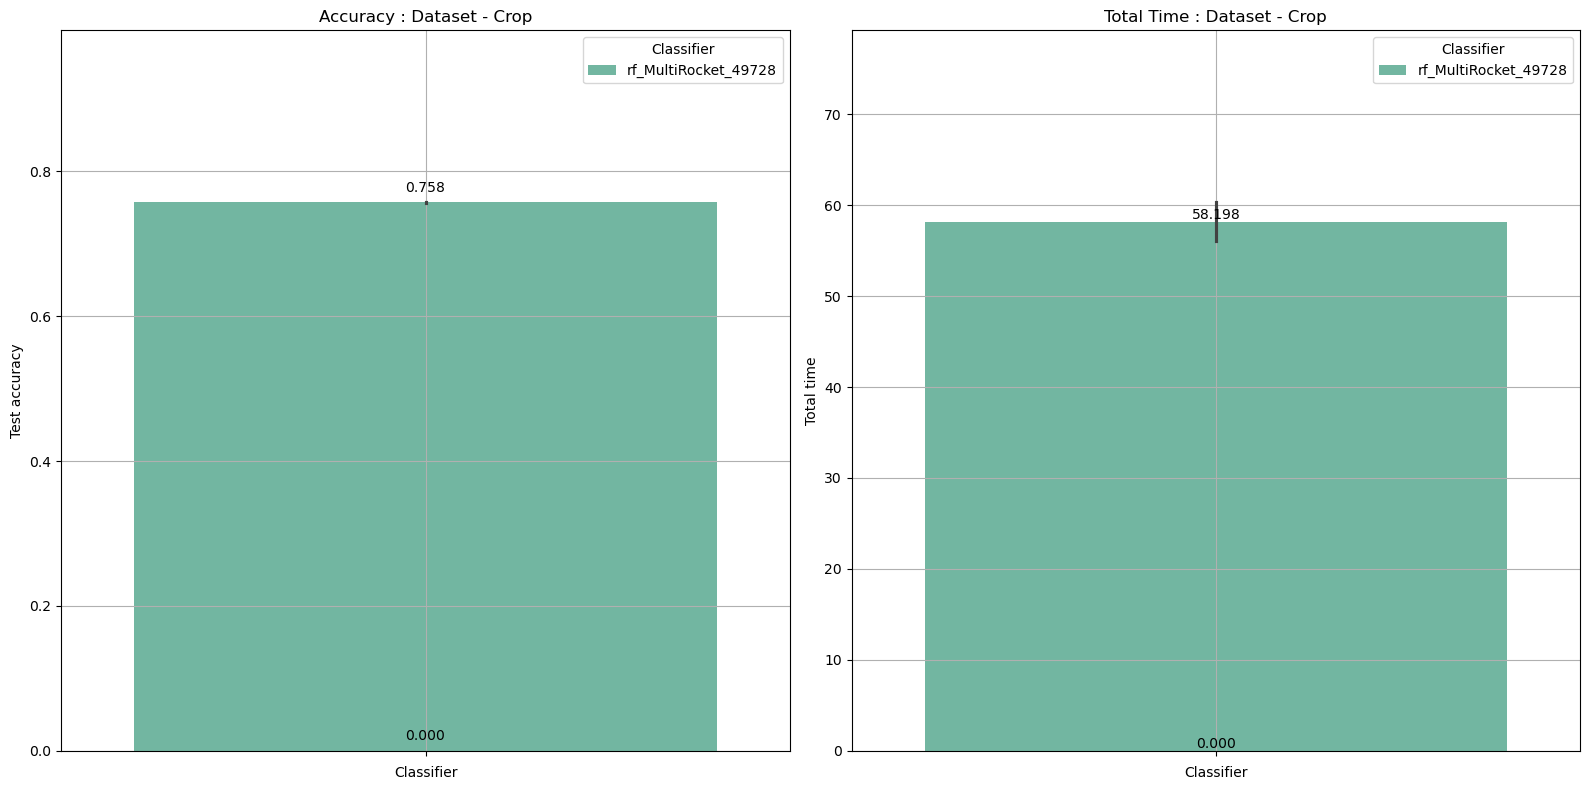

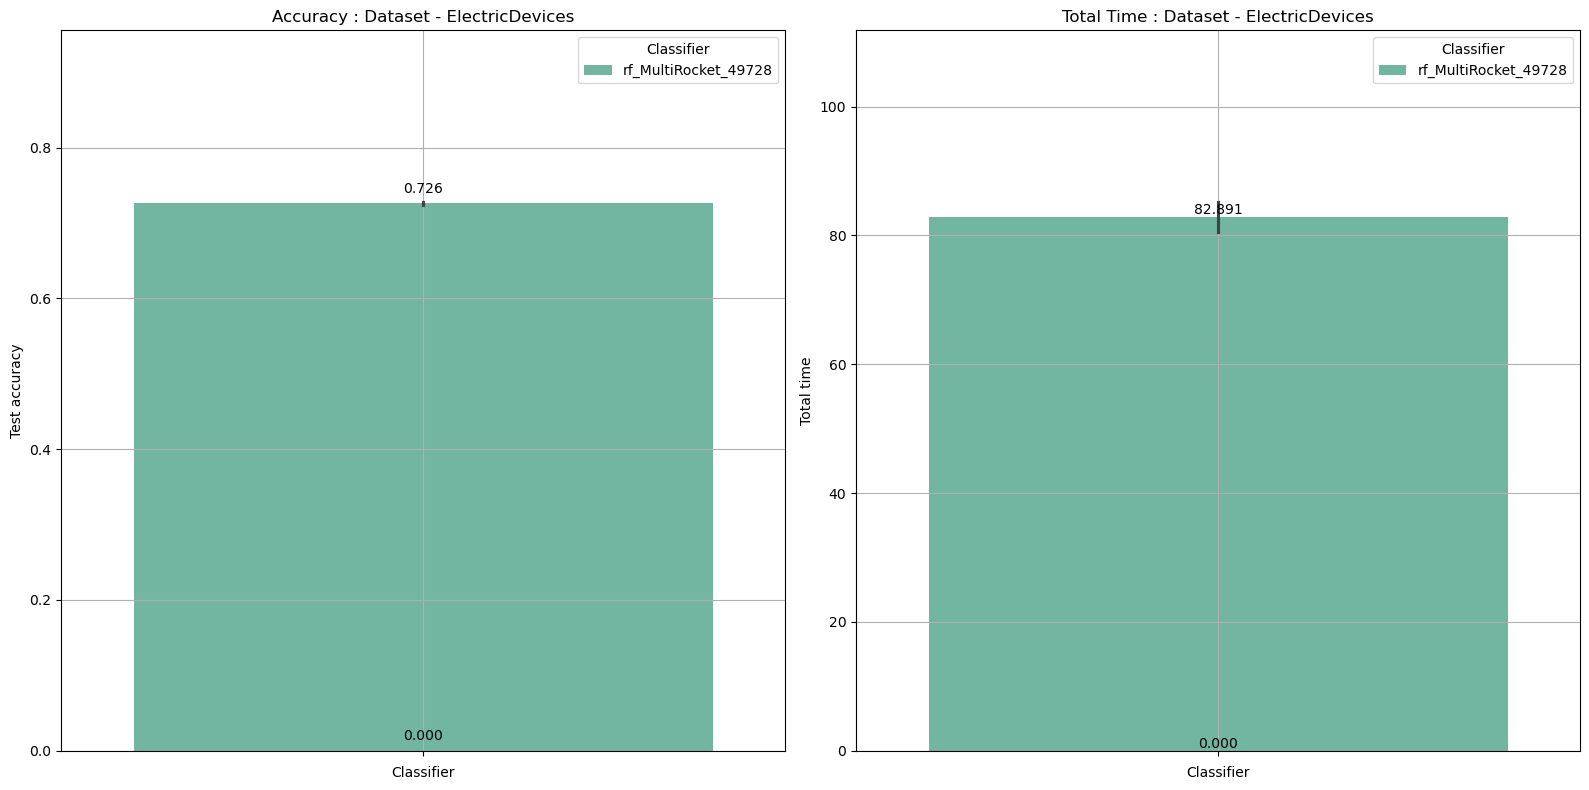

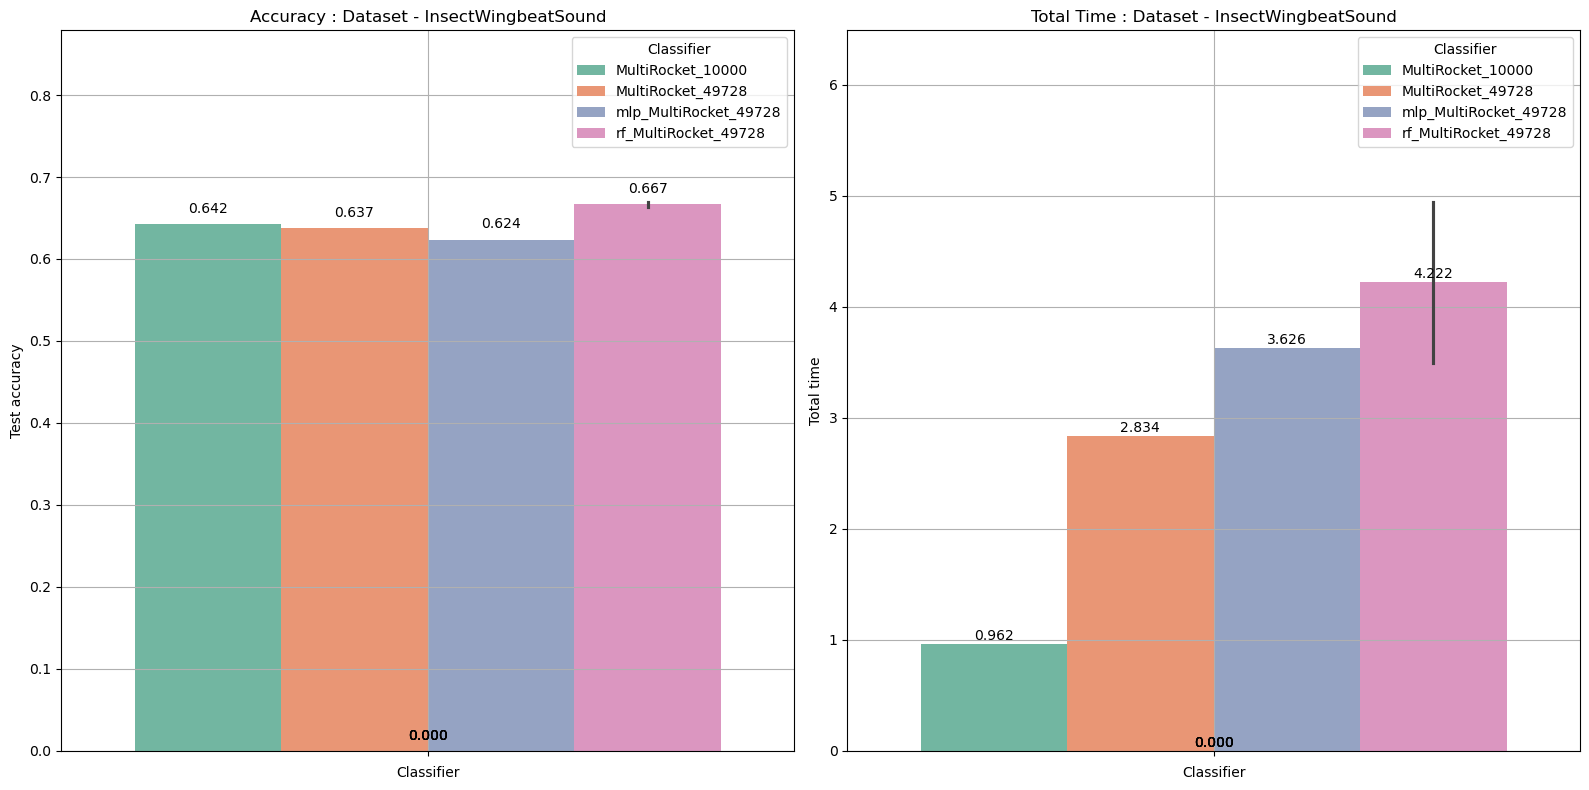

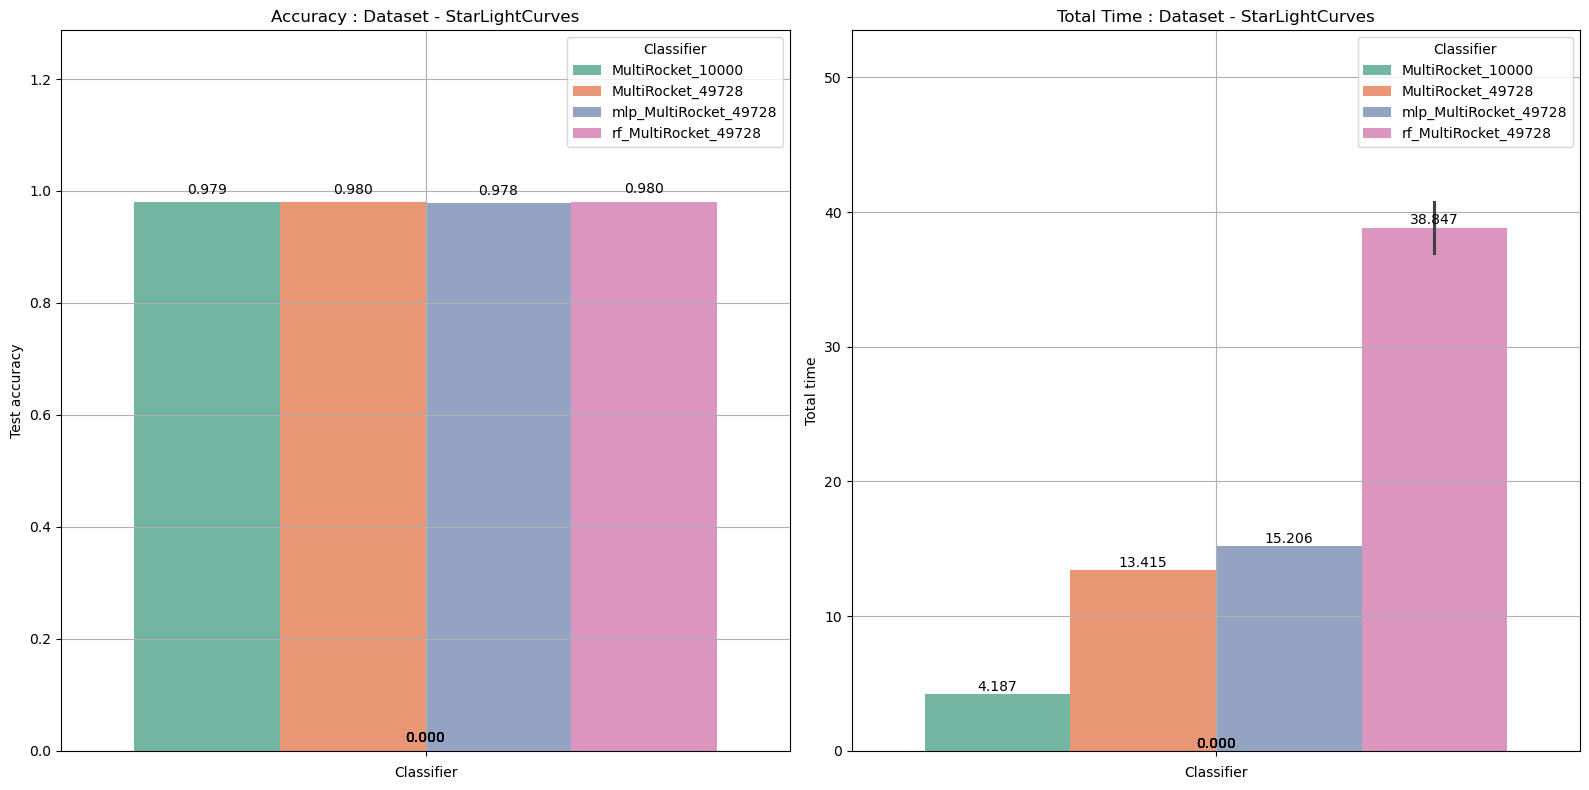

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

for dataset in df_v2["dataset"].unique():

    plt.figure(figsize=(16, 8))

    plt.subplot(1, 2, 1)

    ax = sns.barplot(
        data=df_v2[df_v2["dataset"] == dataset],
        y="test_acc",
        hue="classifier",
        palette="Set2"
    )

    plt.title(f"Accuracy : Dataset - {dataset}")
    plt.xlabel("Classifier")
    plt.ylabel("Test accuracy")
    plt.grid(True)

    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax * 1.25)

    for p in ax.patches:
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.text(x, y + 0.01, f"{y:.3f}", ha="center", va="bottom", fontsize=10)

    plt.legend(loc="upper right", title="Classifier")

    plt.subplot(1, 2, 2)

    ax2 = sns.barplot(
        data=df_v2[df_v2["dataset"] == dataset],
        y="total_time",
        hue="classifier",
        palette="Set2"
    )

    plt.title(f"Total Time : Dataset - {dataset}")
    plt.xlabel("Classifier")
    plt.ylabel("Total time")
    plt.grid(True)

    ymin, ymax = ax2.get_ylim()
    ax2.set_ylim(ymin, ymax * 1.25)

    for p in ax2.patches:
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax2.text(x, y + 0.01, f"{y:.3f}", ha="center", va="bottom", fontsize=10)

    plt.legend(loc="upper right", title="Classifier")
    plt.tight_layout()
    plt.show()